In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("../data/cutomer_features.csv")

In [3]:
data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96095 entries, 0 to 96094
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_unique_id   96095 non-null  object 
 1   total_orders         96095 non-null  int64  
 2   total_spent          96095 non-null  float64
 3   average_order_value  96095 non-null  float64
 4   first_purchase       96095 non-null  object 
 5   last_purchase        96095 non-null  object 
 6   recency_days         96095 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 5.1+ MB


In [5]:
data.describe()

,total_orders,total_spent,average_order_value,recency_days
count,96095.000000,96095.000000,96095.000000,96095.000000
mean,1.034809,166.594226,161.401796,288.196437
std,0.214385,231.428912,222.308078,153.409496
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,63.120000,62.460000,163.885689
50%,1.000000,108.000000,105.830000,268.906620
75%,1.000000,183.530000,177.210000,397.349647
max,17.000000,13664.080000,13664.080000,772.843738


In [6]:
data.isnull().sum()

customer_unique_id     0
total_orders           0
total_spent            0
average_order_value    0
first_purchase         0
last_purchase          0
recency_days           0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data["first_purchase"] = pd.to_datetime(data["first_purchase"])
data["last_purchase"] = pd.to_datetime(data["last_purchase"])

In [9]:
data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96095 entries, 0 to 96094
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_unique_id   96095 non-null  object        
 1   total_orders         96095 non-null  int64         
 2   total_spent          96095 non-null  float64       
 3   average_order_value  96095 non-null  float64       
 4   first_purchase       96095 non-null  datetime64[ns]
 5   last_purchase        96095 non-null  datetime64[ns]
 6   recency_days         96095 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(1)
memory usage: 5.1+ MB


In [11]:
numerical_columns = [
    "total_orders",
    "total_spent",
    "average_order_value",
    "recency_days"
]

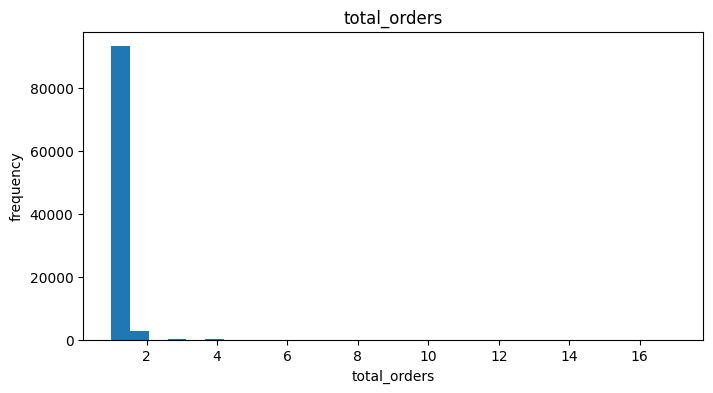

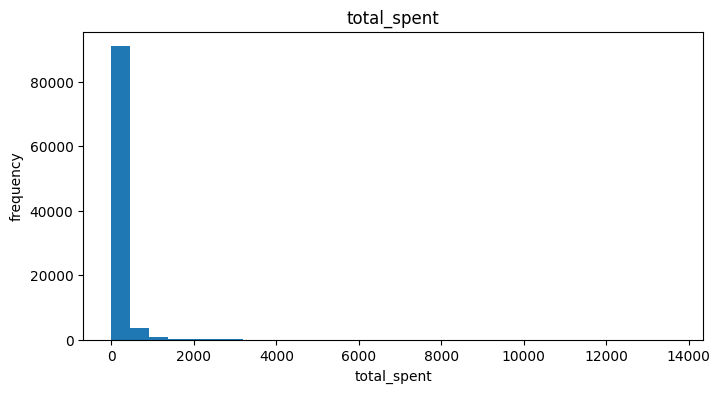

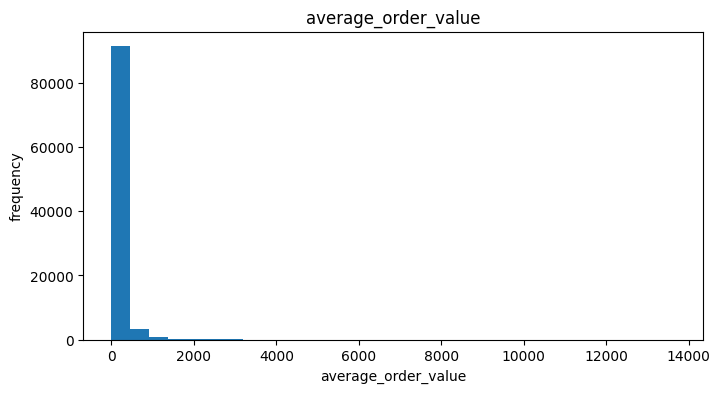

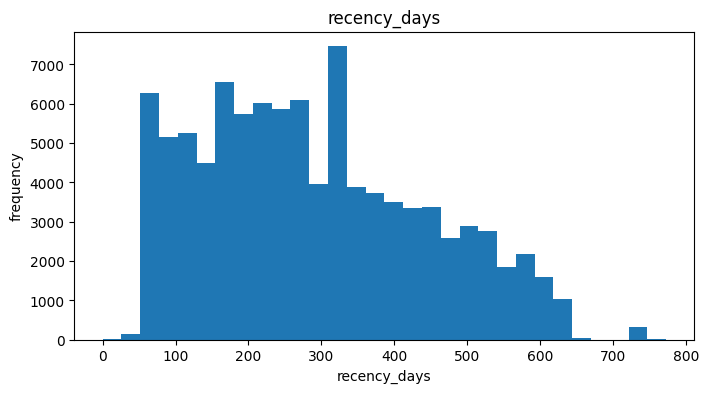

In [12]:
for column in numerical_columns:
    plt.figure(figsize=(8,4))
    plt.hist(data[column], bins=30)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('frequency')
    plt.show()

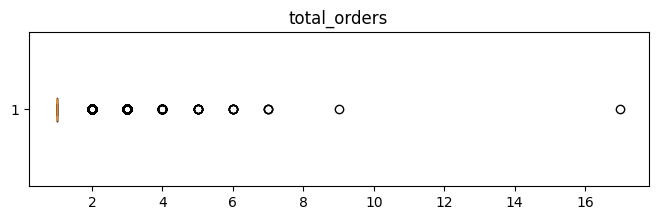

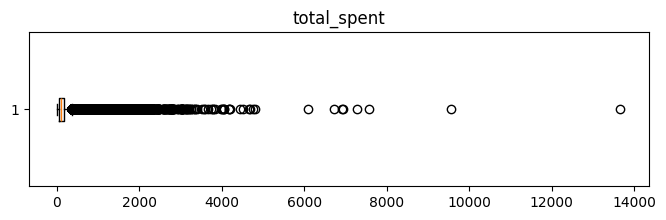

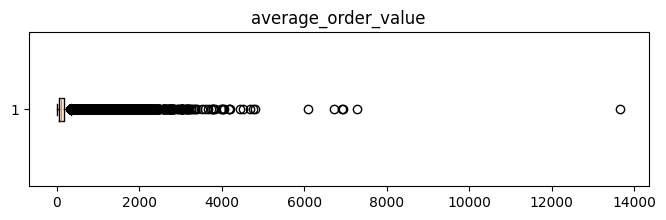

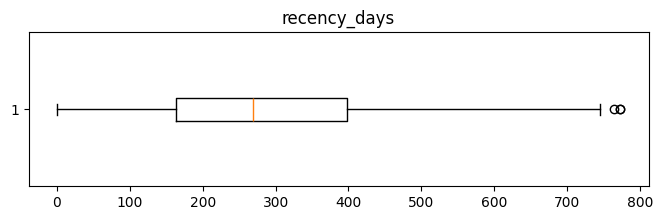

In [13]:
for column in numerical_columns:
    plt.figure(figsize=(8,2))
    plt.boxplot(data[column], vert=False)
    plt.title(column)
    plt.show()

In [14]:
preprocessed_data = data.copy()

In [15]:
skewed_columns = [
    "total_spent",
    "average_order_value"
]
for column in skewed_columns:
    preprocessed_data[column] = np.log1p(preprocessed_data[column])

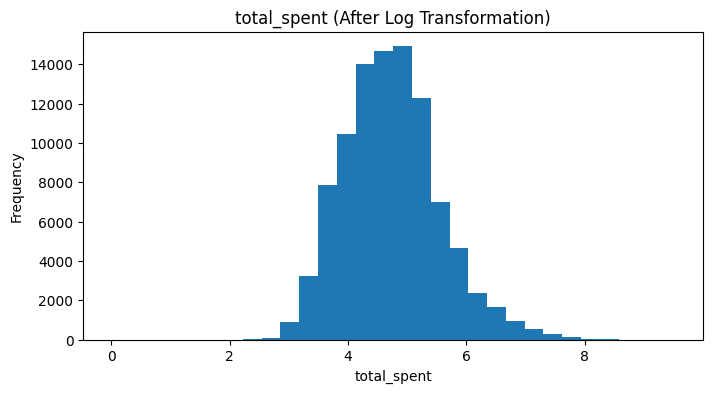

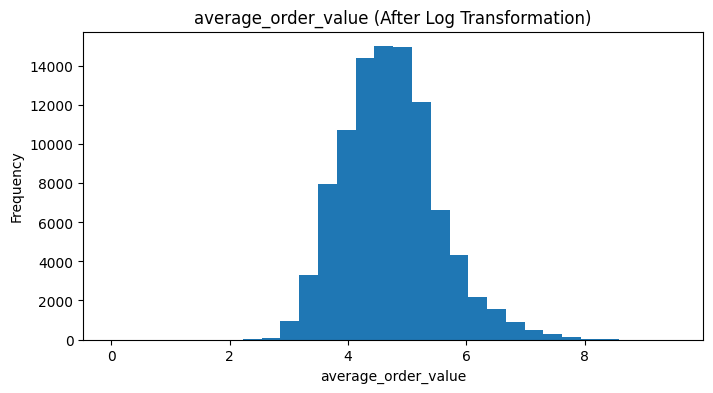

In [16]:
for column in skewed_columns:
    plt.figure(figsize=(8,4))
    plt.hist(preprocessed_data[column], bins=30)
    plt.title(f"{column} (After Log Transformation)")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [17]:
features = [
    "total_orders",
    "total_spent",
    "average_order_value",
    "recency_days"
]

In [18]:
X = preprocessed_data[features]
X.head()

,total_orders,total_spent,average_order_value,recency_days
0,1,9.522599,9.522599,383.087106
1,3,9.164717,8.066314,60.891458
2,2,8.932296,8.239281,564.063623
3,1,8.892320,8.892320,94.111505
4,1,8.843660,8.843660,611.869931


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled

array([[-0.16236915,  5.89897255,  6.01187469,  0.61854817],
       [ 9.16669721,  5.45818715,  4.1925484 , -1.48169551],
       [ 4.50216403,  5.17192483,  4.40863395,  1.79824997],
       ...,
       [-0.16236915, -2.92296199, -2.93642266, -1.53417983],
       [-0.16236915, -5.82954826, -5.88464203, -1.59091636],
       [-0.16236915, -5.82954826, -5.88464203, -1.55213214]],
      shape=(96095, 4))

In [25]:
X_scaled = pd.DataFrame(X_scaled,
                       columns = X.columns,
                       index=X.index)

In [26]:
X_scaled.to_csv("../data/customer_features_preprocessed.csv", index = False)